**1. Lets Do the Necesary Imports and Installation !**

In [1]:
!pip install pandas
!pip install matplotlib
!pip install seaborn
!pip install sklearn
!pip install tensorflow
!pip install keras
!!pip install scikit-learn

  Using cached pandas-3.0.1-cp312-cp312-macosx_11_0_arm64.whl.metadata (79 kB)
  Using cached numpy-2.4.3-cp312-cp312-macosx_14_0_arm64.whl.metadata (6.6 kB)
Using cached pandas-3.0.1-cp312-cp312-macosx_11_0_arm64.whl (9.9 MB)
Using cached numpy-2.4.3-cp312-cp312-macosx_14_0_arm64.whl (5.2 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pandas]2m1/2 [pandas]
  Using cached matplotlib-3.10.8-cp312-cp312-macosx_11_0_arm64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp312-cp312-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.0-cp312-cp312-macosx_10_13_universal2.whl.metadata (117 kB)
  Using cached kiwisolver-1.5.0-cp312-cp312-macosx_11_0_arm64.whl.metadata (5.1 kB)
  Using cached pillow-12.1.1-cp312-cp312-macosx_11_0_arm64.whl.metadata (8.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.8-cp312-cp312-macosx_11_0_arm64.whl (8.1 MB)
Using ca

['Collecting scikit-learn',
 '  Using cached scikit_learn-1.8.0-cp312-cp312-macosx_12_0_arm64.whl.metadata (11 kB)',
 'Requirement already satisfied: numpy>=1.24.1 in /Users/aryan/miniconda3/envs/my_ml_project/lib/python3.12/site-packages (from scikit-learn) (2.4.3)',
 'Collecting scipy>=1.10.0 (from scikit-learn)',
 '  Using cached scipy-1.17.1-cp312-cp312-macosx_14_0_arm64.whl.metadata (62 kB)',
 'Collecting joblib>=1.3.0 (from scikit-learn)',
 '  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)',
 'Collecting threadpoolctl>=3.2.0 (from scikit-learn)',
 '  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)',
 'Using cached scikit_learn-1.8.0-cp312-cp312-macosx_12_0_arm64.whl (8.1 MB)',
 'Using cached joblib-1.5.3-py3-none-any.whl (309 kB)',
 'Using cached scipy-1.17.1-cp312-cp312-macosx_14_0_arm64.whl (20.3 MB)',
 'Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)',
 'Installing collected packages: threadpoolctl, scipy, joblib, scikit-learn',
 '\x1

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import mean_absolute_error, r2_score, classification_report, silhouette_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import warnings

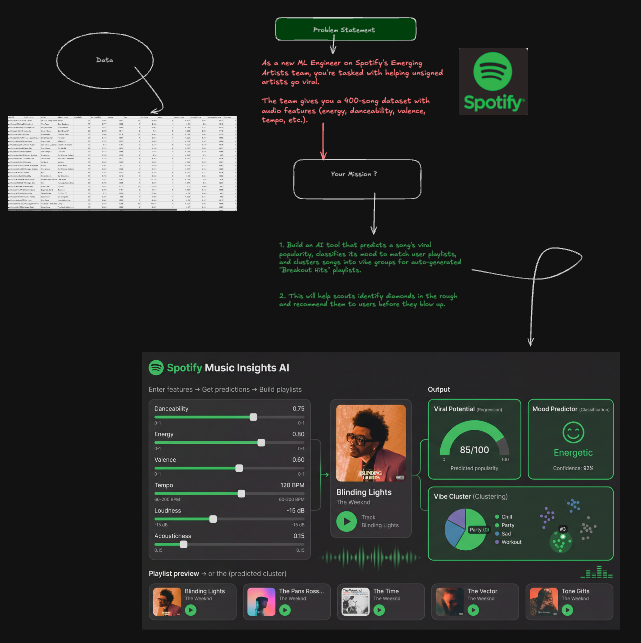

**GOLDEN-RULE**

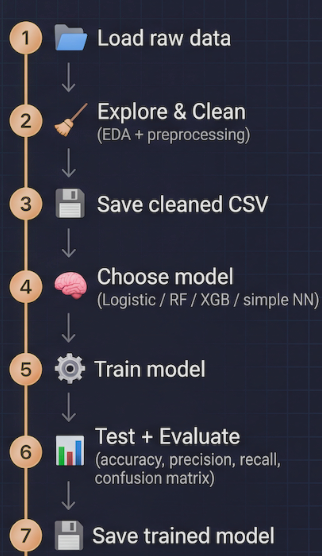

**1.1 --> Define Problem Statement !**

As a new ML Engineer on Spotify's Emerging Artists team, you're tasked with helping unsigned artists go viral. 

The team gives you a 400-song dataset with audio features (energy, danceability, valence, tempo, etc.).

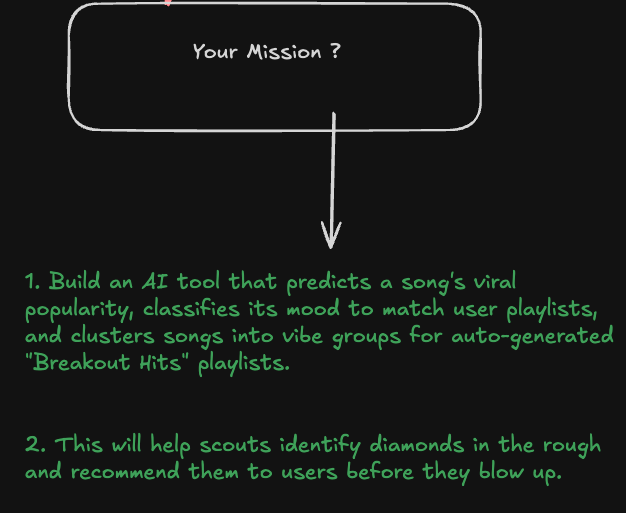

**Solution is -->**

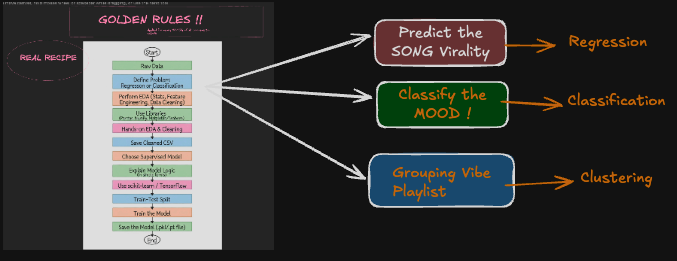

**Step 1: Raw Data – Load & Understand !**

In [3]:
import pandas as pd 

df = pd.read_csv('spotify_400.csv')

In [4]:
df.head(10)

,track_id,track_name,artists,album_name,popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,genre,mood
0,spotify:track:3ii7r7exn5vhQYMbQI8788,Mi Gente,"J Balvin, Willy William",Vibras,66.0,0.688,0.603,10.0,-6.469,0.0,0.107,0.091,0.012,NaN,0.785,90.675,4.0,latin,happy
1,spotify:track:Mz2tayEqBsCELPEy4ZbZTY,Silver Soul,Alex Page,Soul Sessions,77.0,0.777,0.705,7.0,-2.432,1.0,0.040,0.280,NaN,0.067,0.715,98.629,4.0,pop,happy
2,spotify:track:e94RNjDxdhfYqK8rcqANkU,Fading Echo,Morgan Blake,Echo Diaries,74.0,0.621,0.665,4.0,-5.007,1.0,0.049,0.251,0.019,0.221,0.676,113.296,4.0,pop,happy
3,spotify:track:vkdiivHywnPhaCG6p9ry9R,Animals,Martin Garrix,Gold Skies EP,66.0,NaN,0.944,2.0,-4.010,0.0,0.082,0.033,0.116,0.093,0.789,127.822,NaN,electronic,motivational
4,spotify:track:JzRmCXCaBlAQPVVWfgZiOJ,Faded,Alan Walker,Different World,62.0,0.686,0.718,11.0,-4.803,0.0,0.088,0.063,0.325,0.056,0.495,135.856,4.0,electronic,angry
5,spotify:track:56wWf8HeSFueXLEhxnIFsY,Tennessee Whiskey,Chris Stapleton,Traveller,54.0,0.444,0.501,4.0,-6.657,1.0,0.066,NaN,0.005,0.233,0.423,121.190,4.0,country,sad
6,spotify:track:qWxQFaa9LSGUSbsKbbt4ma,Anti-Hero,Taylor Swift,Midnights,80.0,0.742,0.777,9.0,-5.563,1.0,0.076,0.267,0.008,0.056,0.426,128.559,3.0,pop,motivational
7,spotify:track:gcpaOETRg00vlVRoP8u26S,Danza Kuduro,"Don Omar, Lucenzo",Meet the Orphans,75.0,0.710,0.784,9.0,-5.473,0.0,0.053,0.179,0.048,0.099,0.814,121.668,4.0,latin,happy
8,spotify:track:4nBve8lWdbPq8yXtBQkJcq,Neon Sky,Alex Chase,Our Sky EP,88.0,0.741,0.834,9.0,-4.166,0.0,0.037,0.084,0.031,0.203,0.422,109.583,4.0,pop,motivational
9,spotify:track:SCyaRDcqzYh54tef4Ezn23,Elephant,Tame Impala,Lonerism,57.0,0.544,0.656,7.0,-7.845,1.0,0.088,0.186,0.055,NaN,0.346,100.636,4.0,indie,motivational


In [5]:
df

,track_id,track_name,artists,album_name,popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,genre,mood
0,spotify:track:3ii7r7exn5vhQYMbQI8788,Mi Gente,"J Balvin, Willy William",Vibras,66.0,0.688,0.603,10.0,-6.469,0.0,0.107,0.091,0.012,NaN,0.785,90.675,4.0,latin,happy
1,spotify:track:Mz2tayEqBsCELPEy4ZbZTY,Silver Soul,Alex Page,Soul Sessions,77.0,0.777,0.705,7.0,-2.432,1.0,0.040,0.280,NaN,0.067,0.715,98.629,4.0,pop,happy
2,spotify:track:e94RNjDxdhfYqK8rcqANkU,Fading Echo,Morgan Blake,Echo Diaries,74.0,0.621,0.665,4.0,-5.007,1.0,0.049,0.251,0.019,0.221,0.676,113.296,4.0,pop,happy
3,spotify:track:vkdiivHywnPhaCG6p9ry9R,Animals,Martin Garrix,Gold Skies EP,66.0,NaN,0.944,2.0,-4.010,0.0,0.082,0.033,0.116,0.093,0.789,127.822,NaN,electronic,motivational
4,spotify:track:JzRmCXCaBlAQPVVWfgZiOJ,Faded,Alan Walker,Different World,62.0,0.686,0.718,11.0,-4.803,0.0,0.088,0.063,0.325,0.056,0.495,135.856,4.0,electronic,angry
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,spotify:track:GQRrcKH7H1iWTsimoYUzCR,Fading Night,Drew Rivers,Night Sessions,68.0,0.553,0.850,NaN,-7.161,1.0,0.036,0.041,0.107,0.078,0.524,155.617,4.0,rock,motivational
396,spotify:track:Obr4GIt6ibWrBgrnGdRiaE,Crystal Shadow,Skylar Lane,Your Shadow EP,76.0,0.477,0.685,8.0,-7.855,1.0,0.035,0.045,0.029,0.248,0.718,108.252,4.0,rock,happy
397,spotify:track:nBRNtp3FaBNfBMohNkyAxr,Blinding Lights,The Weeknd,After Hours,78.0,0.652,0.554,11.0,-7.444,NaN,0.039,0.300,0.030,0.211,0.831,111.830,4.0,pop,happy
398,spotify:track:rHdqIt88wcE3Fdt7EnxTDV,Lost Heart,Jamie Ray,Heart EP,81.0,0.722,0.616,9.0,-6.232,1.0,0.045,0.249,0.030,NaN,0.559,143.888,3.0,pop,happy


In [6]:
print("Shape:", df.shape)
print("\nFirst 3 rows:")
print(df.head(3))
print("\nColumns:", df.columns.tolist())
print("\nMissing values:\n", df.isnull().sum())

Shape: (400, 19)

First 3 rows:
                               track_id   track_name                  artists  \
0  spotify:track:3ii7r7exn5vhQYMbQI8788     Mi Gente  J Balvin, Willy William   
1  spotify:track:Mz2tayEqBsCELPEy4ZbZTY  Silver Soul                Alex Page   
2  spotify:track:e94RNjDxdhfYqK8rcqANkU  Fading Echo             Morgan Blake   

      album_name  popularity  danceability  energy   key  loudness  mode  \
0         Vibras        66.0         0.688   0.603  10.0    -6.469   0.0   
1  Soul Sessions        77.0         0.777   0.705   7.0    -2.432   1.0   
2   Echo Diaries        74.0         0.621   0.665   4.0    -5.007   1.0   

   speechiness  acousticness  instrumentalness  liveness  valence    tempo  \
0        0.107         0.091             0.012       NaN    0.785   90.675   
1        0.040         0.280               NaN     0.067    0.715   98.629   
2        0.049         0.251             0.019     0.221    0.676  113.296   

   time_signature  genre 

**Quick look at targets**

In [10]:
df[["popularity"]].min()

popularity   -30.334
dtype: float64

In [11]:
df[["popularity"]].max()

popularity    150.402
dtype: float64

In [14]:
df['mood'].unique()

<StringArray>
[       'happy', 'motivational',        'angry',          'sad',
    'energetic',        'chill',            nan,      'relaxed',
          '???',  '##corrupt##',         'NONE']
Length: 11, dtype: str

In [7]:
print("\nPopularity range:", df['popularity'].min(), "to", df['popularity'].max())
print("Unique moods:", df['mood'].unique())
print("Unique genres:", df['genre'].unique())


Popularity range: -30.334 to 150.402
Unique moods: <StringArray>
[       'happy', 'motivational',        'angry',          'sad',
    'energetic',        'chill',            nan,      'relaxed',
          '???',  '##corrupt##',         'NONE']
Length: 11, dtype: str
Unique genres: <StringArray>
[      'latin',         'pop',  'electronic',     'country',       'indie',
      'hiphop',        'rock',        'jazz',         'rnb',       'metal',
           nan,   'classical',        'folk',     'UNKNOWN',         '???',
 '##corrupt##']
Length: 16, dtype: str


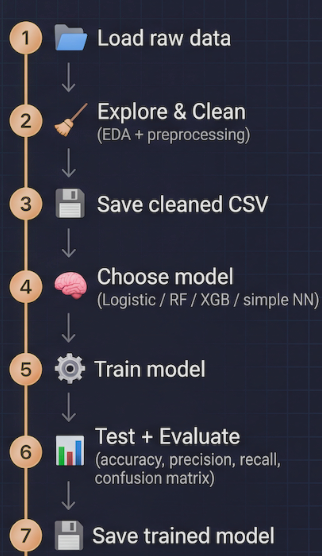

**2.Explore and Clean Data**

In [15]:
print("\nStep 2: EDA & Cleaning")


Step 2: EDA & Cleaning


2.1 --> Basic Stats !

In [16]:
print(df.describe())

       popularity  danceability      energy         key    loudness  \
count  380.000000    380.000000  380.000000  380.000000  381.000000   
mean    70.688426      0.635787    0.668663    5.616247   -7.332942   
std     19.271694      0.247591    0.249521    3.718419   10.526125   
min    -30.334000     -0.943000   -0.991000   -5.352000  -80.236000   
25%     65.000000      0.552750    0.588000    3.000000   -7.297000   
50%     74.000000      0.672000    0.683500    6.000000   -5.677000   
75%     80.000000      0.758000    0.774000    9.000000   -3.969000   
max    150.402000      2.503000    2.457000   19.994000   20.432000   

             mode  speechiness  acousticness  instrumentalness    liveness  \
count  380.000000   381.000000    380.000000        381.000000  380.000000   
mean     0.510526     0.135273      0.202366          0.112312    0.165097   
std      0.500548     0.254803      0.266953          0.285058    0.182923   
min      0.000000    -0.925000     -0.821000    

2.2 --> Show the Noise !!

In [17]:
df

,track_id,track_name,artists,album_name,popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,genre,mood
0,spotify:track:3ii7r7exn5vhQYMbQI8788,Mi Gente,"J Balvin, Willy William",Vibras,66.0,0.688,0.603,10.0,-6.469,0.0,0.107,0.091,0.012,NaN,0.785,90.675,4.0,latin,happy
1,spotify:track:Mz2tayEqBsCELPEy4ZbZTY,Silver Soul,Alex Page,Soul Sessions,77.0,0.777,0.705,7.0,-2.432,1.0,0.040,0.280,NaN,0.067,0.715,98.629,4.0,pop,happy
2,spotify:track:e94RNjDxdhfYqK8rcqANkU,Fading Echo,Morgan Blake,Echo Diaries,74.0,0.621,0.665,4.0,-5.007,1.0,0.049,0.251,0.019,0.221,0.676,113.296,4.0,pop,happy
3,spotify:track:vkdiivHywnPhaCG6p9ry9R,Animals,Martin Garrix,Gold Skies EP,66.0,NaN,0.944,2.0,-4.010,0.0,0.082,0.033,0.116,0.093,0.789,127.822,NaN,electronic,motivational
4,spotify:track:JzRmCXCaBlAQPVVWfgZiOJ,Faded,Alan Walker,Different World,62.0,0.686,0.718,11.0,-4.803,0.0,0.088,0.063,0.325,0.056,0.495,135.856,4.0,electronic,angry
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,spotify:track:GQRrcKH7H1iWTsimoYUzCR,Fading Night,Drew Rivers,Night Sessions,68.0,0.553,0.850,NaN,-7.161,1.0,0.036,0.041,0.107,0.078,0.524,155.617,4.0,rock,motivational
396,spotify:track:Obr4GIt6ibWrBgrnGdRiaE,Crystal Shadow,Skylar Lane,Your Shadow EP,76.0,0.477,0.685,8.0,-7.855,1.0,0.035,0.045,0.029,0.248,0.718,108.252,4.0,rock,happy
397,spotify:track:nBRNtp3FaBNfBMohNkyAxr,Blinding Lights,The Weeknd,After Hours,78.0,0.652,0.554,11.0,-7.444,NaN,0.039,0.300,0.030,0.211,0.831,111.830,4.0,pop,happy
398,spotify:track:rHdqIt88wcE3Fdt7EnxTDV,Lost Heart,Jamie Ray,Heart EP,81.0,0.722,0.616,9.0,-6.232,1.0,0.045,0.249,0.030,NaN,0.559,143.888,3.0,pop,happy


In [18]:
print("\nMissing values count :")
print(df.isnull().sum())


Missing values count :
track_id             0
track_name           0
artists              0
album_name           0
popularity          20
danceability        20
energy              20
key                 20
loudness            19
mode                20
speechiness         19
acousticness        20
instrumentalness    19
liveness            20
valence             20
tempo               19
time_signature      20
genre               21
mood                21
dtype: int64


In [19]:
print("\nUnique values in genre and mood (look for corrupt ones):")


Unique values in genre and mood (look for corrupt ones):


In [20]:
print("genre:", df['genre'].unique())   
print("mood:", df['mood'].unique())

genre: <StringArray>
[      'latin',         'pop',  'electronic',     'country',       'indie',
      'hiphop',        'rock',        'jazz',         'rnb',       'metal',
           nan,   'classical',        'folk',     'UNKNOWN',         '???',
 '##corrupt##']
Length: 16, dtype: str
mood: <StringArray>
[       'happy', 'motivational',        'angry',          'sad',
    'energetic',        'chill',            nan,      'relaxed',
          '???',  '##corrupt##',         'NONE']
Length: 11, dtype: str


2.3 --> Simple Cleaning !

In [22]:
for types in df.columns:
    print(f"{types} unique values: {df[types].dtypes}")

track_id unique values: str
track_name unique values: str
artists unique values: str
album_name unique values: str
popularity unique values: float64
danceability unique values: float64
energy unique values: float64
key unique values: float64
loudness unique values: float64
mode unique values: float64
speechiness unique values: float64
acousticness unique values: float64
instrumentalness unique values: float64
liveness unique values: float64
valence unique values: float64
tempo unique values: float64
time_signature unique values: float64
genre unique values: str
mood unique values: str


A . Fill missing numeric values and median !

In [23]:
numeric_cols = df.select_dtypes(include=[np.number]).columns

In [24]:
numeric_cols

Index(['popularity', 'danceability', 'energy', 'key', 'loudness', 'mode',
       'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'time_signature'],
      dtype='str')

In [27]:
for col in numeric_cols:
    if df[col].isnull().any():
        median_value = df[col].median()
        df[col] = df[col].fillna(median_value)
        print(f"Filled missing values in '{col}' with median: {median_value}")

B. Filling the missing categorical values !

In [28]:
cat_cols = ['genre', 'mood', 'track_name', 'artists', 'album_name']


In [29]:
df[["mood"]]

,mood
0,happy
1,happy
2,happy
3,motivational
4,angry
...,...
395,motivational
396,happy
397,happy
398,happy


In [30]:
df[['mood']].mode()

,mood
0,happy


In [31]:
for cat_col in cat_cols:
    if df[cat_col].isnull().any():
        mode_result = df[cat_col].mode()
        if len(mode_result) > 0:
            mode_value = mode_result[0]
            df[cat_col].fillna(mode_value, inplace=True)
            print(f"Filled missing values in '{cat_col}' with mode: {mode_value}")
        else:
            print(f"Warning: No mode found for '{cat_col}', filling with 'Unknown'")

Filled missing values in 'genre' with mode: pop
Filled missing values in 'mood' with mode: happy


/var/folders/_c/xp87xx951rlfpxv00pk8gt580000gn/T/ipykernel_20790/1352127077.py:6: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df[cat_col].fillna(mode_value, inplace=True)


In [40]:
for col in ['genre', 'mood']:
    if col in df.columns:
        # Count remaining NaNs
        nan_count_before = df[col].isnull().sum()
        if nan_count_before > 0:
            # Get mode from non-null values only
            mode_value = df[col].dropna().mode()[0]

            df[col] = df[col].fillna(mode_value)
        else:
            print("No NaN values found")

C. Fix corrupt/invalid categorical values !

In [41]:
invalid_values = ["UNKNOWN", "???", "##corrupt##", "N/A", "", "null", "None"]

In [42]:
for col in df.columns:
    if df[col].dtype == 'object':  # Only check string columns
        df[col] = df[col].replace(invalid_values, np.nan)  # Replace invalid values with NaN
        if df[col].isnull().any():
            mode_result = df[col].mode()
            if len(mode_result) > 0:
                mode_value = mode_result[0]
                df[col].fillna(mode_value, inplace=True)  # Fill NaN with mode
                print(f"Filled invalid values in '{col}' with mode: {mode_value}")
            else:
                print(f"Warning: No mode found for '{col}', filling with 'Unknown'")
                df[col].fillna("Unknown", inplace=True)  # Fill NaN with "Unknown"

D. Simple outlier capping: mean ± 3*std for all numeric columns ! or one may also use the IQR to detect the outlier !!

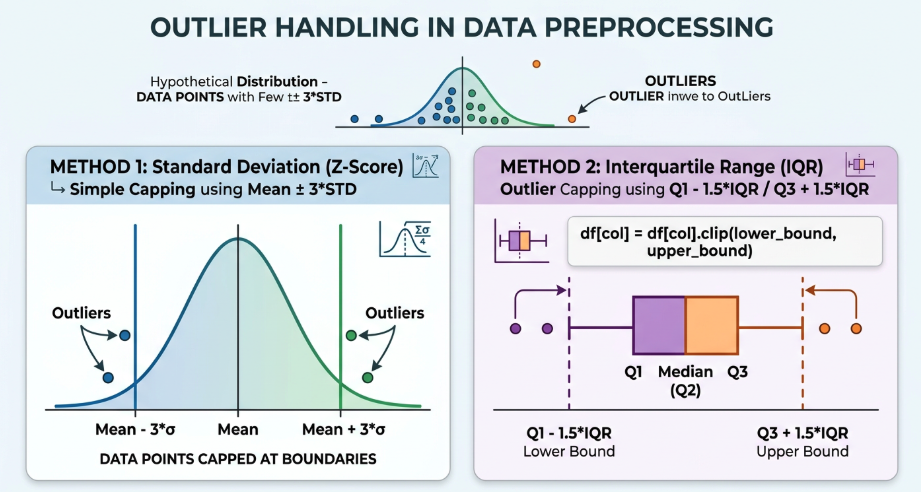

In [43]:
def cap_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower_bound, upper_bound)
    return df

In [44]:
outlier_cols = ['popularity', 'danceability', 'energy', 'loudness', 'speechiness',
                'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']

In [45]:
print("\nCapping outliers in following columns:")
for col in outlier_cols:
    if col in df.columns:
        df = cap_outliers(df, col)
        print(f"→ {col} capped (IQR method)")


Capping outliers in following columns:
→ popularity capped (IQR method)
→ danceability capped (IQR method)
→ energy capped (IQR method)
→ loudness capped (IQR method)
→ speechiness capped (IQR method)
→ acousticness capped (IQR method)
→ instrumentalness capped (IQR method)
→ liveness capped (IQR method)
→ valence capped (IQR method)
→ tempo capped (IQR method)


E. Final Check AFTER CLEANING !

In [47]:
print("\nAfter full cleaning:")
print("Missing values now:\n", df.isnull().sum())
print("\nNumeric summary after capping:\n", df.describe())


After full cleaning:
Missing values now:
 track_id            0
track_name          0
artists             0
album_name          0
popularity          0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
genre               0
mood                0
dtype: int64

Numeric summary after capping:
        popularity  danceability      energy         key    loudness  \
count  400.000000    400.000000  400.000000  400.000000  400.000000   
mean    71.592500      0.644247    0.673724    5.635435   -5.896879   
std     12.716159      0.162129    0.141398    3.624995    2.497924   
min     45.000000      0.257000    0.332125   -5.352000  -11.888625   
25%     66.000000      0.557000    0.594250    3.000000   -7.178250   
50%     74.000000      0.672000    0.683500    6.000000   -5.677000

F . SAVE THE CSV FILE !!

In [48]:
df

,track_id,track_name,artists,album_name,popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,genre,mood
0,spotify:track:3ii7r7exn5vhQYMbQI8788,Mi Gente,"J Balvin, Willy William",Vibras,66.0,0.688,0.603,10.0,-6.469,0.0,0.107,0.091,0.0120,0.163,0.785,90.675,4.0,latin,happy
1,spotify:track:Mz2tayEqBsCELPEy4ZbZTY,Silver Soul,Alex Page,Soul Sessions,77.0,0.777,0.705,7.0,-2.432,1.0,0.040,0.280,0.0300,0.067,0.715,98.629,4.0,pop,happy
2,spotify:track:e94RNjDxdhfYqK8rcqANkU,Fading Echo,Morgan Blake,Echo Diaries,74.0,0.621,0.665,4.0,-5.007,1.0,0.049,0.251,0.0190,0.221,0.676,113.296,4.0,pop,happy
3,spotify:track:vkdiivHywnPhaCG6p9ry9R,Animals,Martin Garrix,Gold Skies EP,66.0,0.672,0.944,2.0,-4.010,0.0,0.082,0.033,0.1160,0.093,0.789,127.822,4.0,electronic,motivational
4,spotify:track:JzRmCXCaBlAQPVVWfgZiOJ,Faded,Alan Walker,Different World,62.0,0.686,0.718,11.0,-4.803,0.0,0.088,0.063,0.1365,0.056,0.495,135.856,4.0,electronic,angry
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,spotify:track:GQRrcKH7H1iWTsimoYUzCR,Fading Night,Drew Rivers,Night Sessions,68.0,0.553,0.850,6.0,-7.161,1.0,0.036,0.041,0.1070,0.078,0.524,155.617,4.0,rock,motivational
396,spotify:track:Obr4GIt6ibWrBgrnGdRiaE,Crystal Shadow,Skylar Lane,Your Shadow EP,76.0,0.477,0.685,8.0,-7.855,1.0,0.035,0.045,0.0290,0.248,0.718,108.252,4.0,rock,happy
397,spotify:track:nBRNtp3FaBNfBMohNkyAxr,Blinding Lights,The Weeknd,After Hours,78.0,0.652,0.554,11.0,-7.444,1.0,0.039,0.300,0.0300,0.211,0.831,111.830,4.0,pop,happy
398,spotify:track:rHdqIt88wcE3Fdt7EnxTDV,Lost Heart,Jamie Ray,Heart EP,81.0,0.722,0.616,9.0,-6.232,1.0,0.045,0.249,0.0300,0.163,0.559,143.888,3.0,pop,happy


In [49]:
df.to_csv('cleaned_data.csv', index=False)

**3. LET'S PERFORM THE EDA**

3.1 --> MOOD DISTRIBUTION !

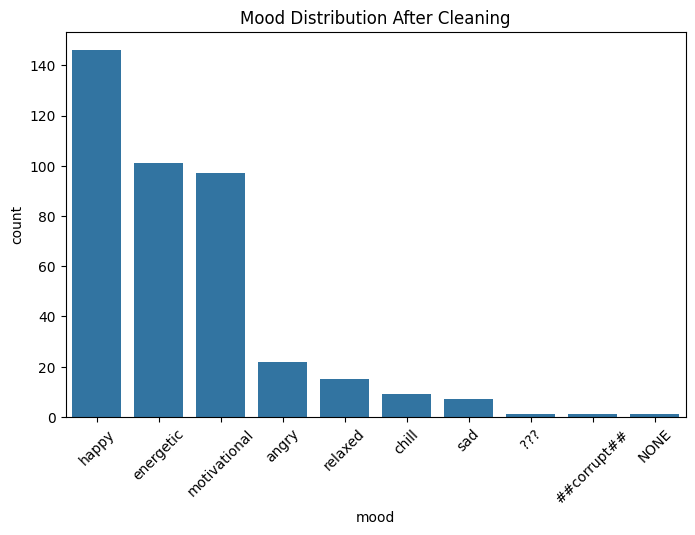

In [50]:
plt.figure(figsize=(8,5))
sns.countplot(x='mood', data=df, order=df['mood'].value_counts().index)
plt.title('Mood Distribution After Cleaning')
plt.xticks(rotation=45)
plt.show()

3.2 --> GENRE DISTRIBUTION !

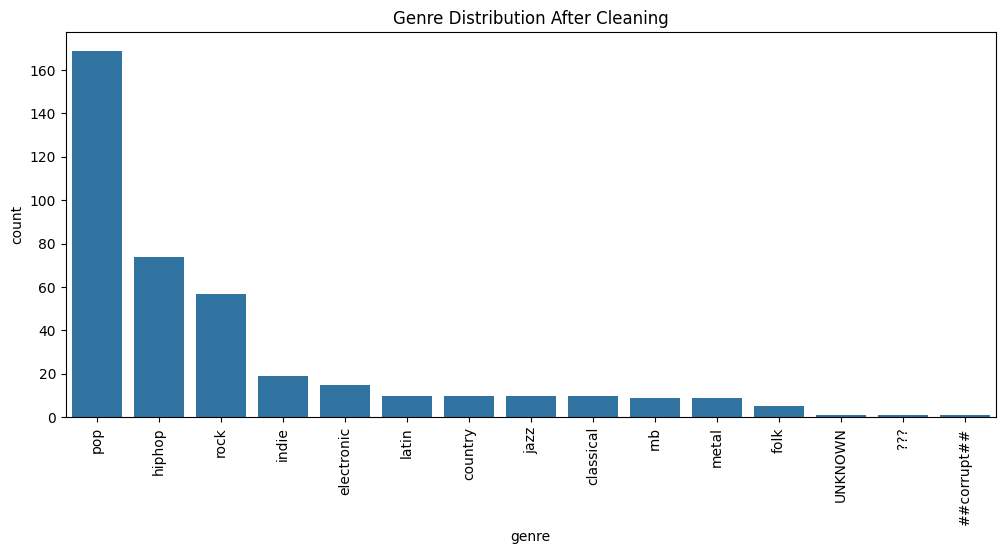

In [51]:
plt.figure(figsize=(12,5))
sns.countplot(x='genre', data=df, order=df['genre'].value_counts().index)
plt.title('Genre Distribution After Cleaning')
plt.xticks(rotation=90)
plt.show()

3.3 --> CO-RELATION HEATMAP !!

3.4 --> KEY SCATTER PLOT 

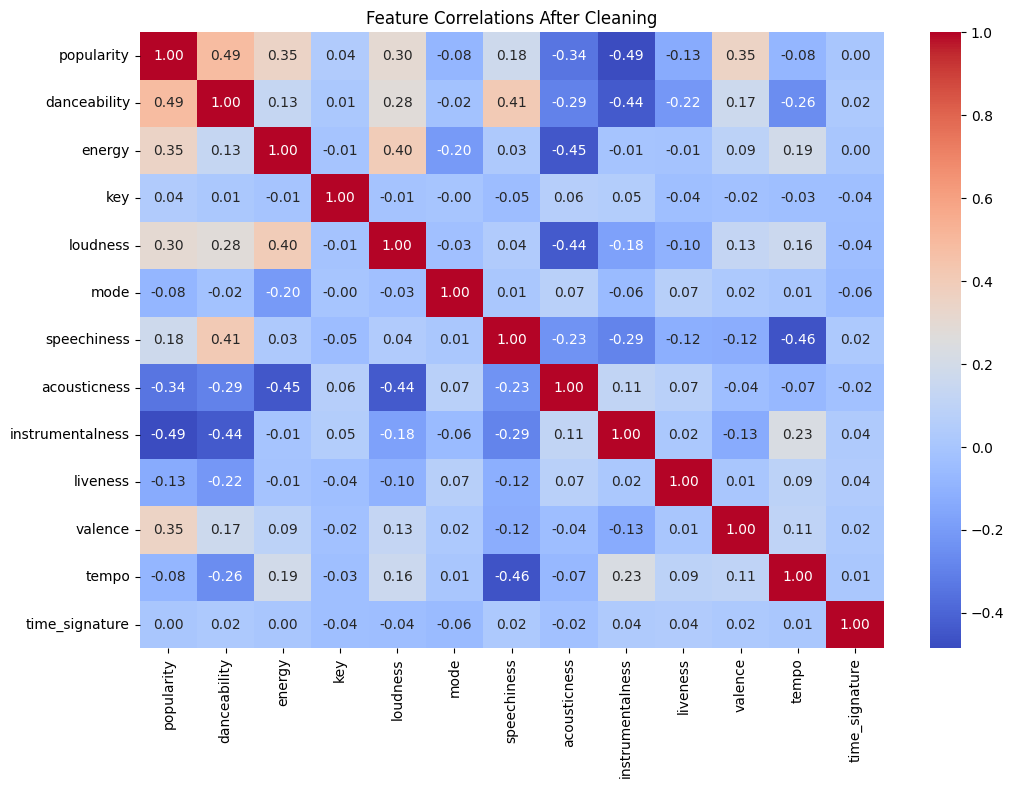

In [52]:
numeric_df = df.select_dtypes(include=np.number)
plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlations After Cleaning')
plt.show()